In [18]:
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    %cd /content/drive/MyDrive/NUIN/motion_CNN
    filepath = "/content/drive/MyDrive/NUIN/mouse_scenes/20210916_252MEA_mouse_right_half_ventral/fixationmovie_data.mat" 
    !git pull
else: 
  filepath =  "mouse_scenes/20210916_252MEA_mouse_right_half_ventral/fixationmovie_data.mat"
    

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/NUIN/motion_CNN
Already up to date.


In [19]:
from utilities import CorrelationVelDataset, show_batch_frames, show_one_sample_summary, sample_animation, split_by_source_image, prerender_dataset_to_single_pt, TensorMovieDataset
from IPython.display import HTML, display
import torch.nn as nn
import torch.nn.functional as F
import torch
from torch.utils.data import Subset, DataLoader
import os 
import numpy as np
import matplotlib.pyplot as plt

# Set the resolution for figures displayed in the notebook
plt.rcParams['figure.dpi'] = 100


In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   
print(f"Using device: {device}")
print(os.getcwd())

Using device: cuda
/content/drive/MyDrive/NUIN/motion_CNN


In [21]:
dataset = CorrelationVelDataset(
    file = filepath,
    crop_hw=(400,400),
    downsample_hw=(50,50),
    frames_per_segment=75,
    fps = 75,
    samples_per_image= 6, 
    vel_std = (350,350),
    vel_corr=-0.0
    )

print("dataset length:", len(dataset))

dataset length: 1950


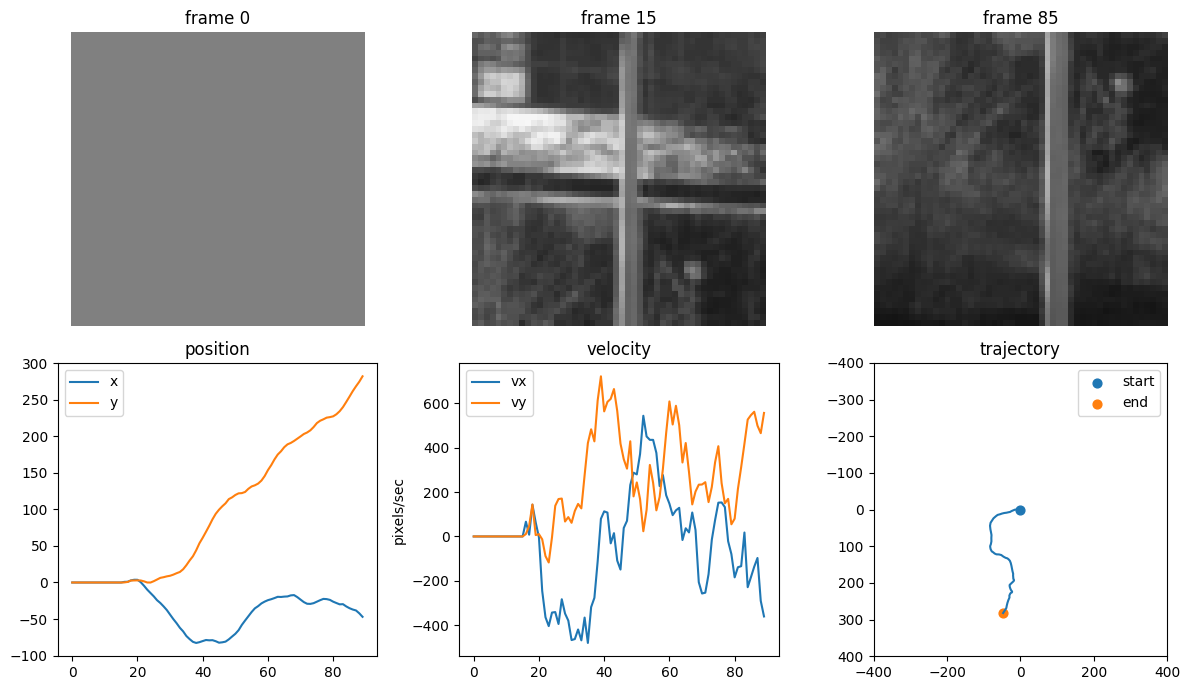

In [22]:
show_one_sample_summary(dataset, 0, frame_indices=[0,15,85])

In [23]:

# anim = sample_animation(dataset, 0, viz_fps=20, save_path=None)
# display(HTML(anim.to_jshtml()))

# Split/Val sets

In [24]:

train_dataset, val_dataset, train_keys, val_keys = split_by_source_image(
    dataset,
    train_frac=0.8,
    val_frac=0.2,
    seed=0,
)
print("Total samples:", len(dataset))
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))

print("Train images:", len(train_keys))
print("Val images:", len(val_keys))

print("Overlap:", len(train_keys & val_keys))

Total samples: 1950
Train samples: 1560
Val samples: 390
Train images: 260
Val images: 65
Overlap: 0


In [25]:
cache_name_train = (
    f"corrvel_train_"
    f"hw{dataset.downsample_hw[0]}x{dataset.downsample_hw[1]}_"
    f"T{dataset.frames_per_segment}_"
    f"gray{dataset.gray_frames}_"
    f"std{dataset.vel_std}_"
    f"corr{dataset.vel_corr}_"
    f"seed{dataset.random_seed}.pt"
)

cache_name_val = (
    f"corrvel_val_"
    f"hw{dataset.downsample_hw[0]}x{dataset.downsample_hw[1]}_"
    f"T{dataset.frames_per_segment}_"
    f"gray{dataset.gray_frames}_"
    f"std{dataset.vel_std}_"
    f"corr{dataset.vel_corr}_"
    f"seed{dataset.random_seed}.pt"
)

train_cache = prerender_dataset_to_single_pt(
    dataset,
    train_dataset.indices,
    f"cache/{cache_name_train}",
    movie_dtype=torch.float16,
    overwrite=False,
)

val_cache = prerender_dataset_to_single_pt(
    dataset,
    val_dataset.indices,
    f"cache/{cache_name_val}",
    movie_dtype=torch.float16,
    overwrite=False,
)

Cache already exists, skipping render: cache/corrvel_train_hw50x50_T75_gray15_std(350, 350)_corr-0.0_seed0.pt
Cache already exists, skipping render: cache/corrvel_val_hw50x50_T75_gray15_std(350, 350)_corr-0.0_seed0.pt


In [26]:
cached_train = TensorMovieDataset(f"cache/{cache_name_train}", movie_dtype=torch.float32)
cached_val = TensorMovieDataset(f"cache/{cache_name_val}", movie_dtype=torch.float32)

train_loader = DataLoader(
    cached_train,
    batch_size=16,
    shuffle=True,
    num_workers=0,   # try 0 first; increase later
    pin_memory=True,
)

val_loader = DataLoader(
    cached_val,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

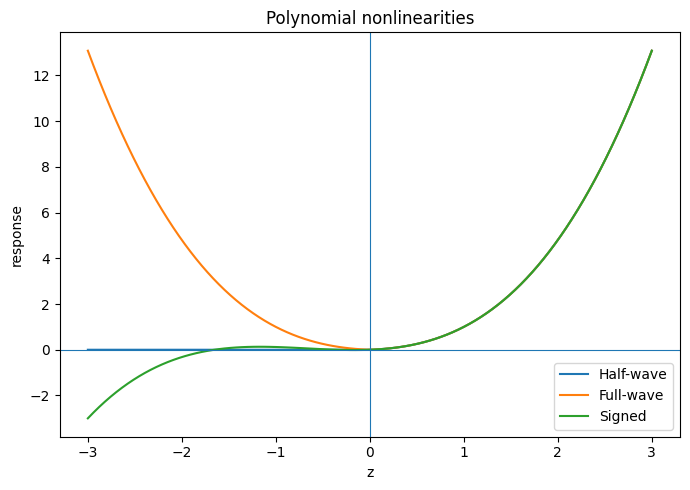

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Coefficients
# -----------------------------
a1, a2, a3 = 0.16 , 0.56 , 0.28

# -----------------------------
# Domain
# -----------------------------
z = np.linspace(-3, 3, 100)

# -----------------------------
# Nonlinearities
# -----------------------------

# Half-wave polynomial:
# phi(z) = a1 [z]_+ + a2 [z]_+^2 + a3 [z]_+^3
z_pos = np.maximum(z, 0)
phi_half = a1 * z_pos + a2 * z_pos**2 + a3 * z_pos**3

# Full-wave polynomial:
# phi_full(z) = a1 |z| + a2 |z|^2 + a3 |z|^3
z_abs = np.abs(z)
phi_full = a1 * z_abs + a2 * z_abs**2 + a3 * z_abs**3

# Signed polynomial:
# phi_signed(z) = a1 z + a2 z^2 + a3 z^3
phi_signed = a1 * z + a2 * z**2 + a3 * z**3


# -----------------------------
# Combined plot
# -----------------------------
plt.figure(figsize=(7, 5))
plt.plot(z, phi_half, label="Half-wave")
plt.plot(z, phi_full, label="Full-wave")
plt.plot(z, phi_signed, label="Signed")
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel("z")
plt.ylabel("response")
plt.title("Polynomial nonlinearities")
plt.legend()
plt.tight_layout()
plt.show()

## Build minimal CNN with separable first layer

In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F


import torch
import torch.nn as nn
import torch.nn.functional as F


class OutputNormalizedSignedPolynomial(nn.Module):
    """
    Signed polynomial with output normalization.

    Computes:
        q_i(z) = pi_i1 z + pi_i2 z^2 + pi_i3 z^3

    Then normalizes each channel's polynomial output:
        phi_i(z) = q_i(z) / RMS(q_i(z))

    This lets pi control the shape of the polynomial while keeping
    the final response scale controlled.
    """

    def __init__(
        self,
        hidden,
        init_mixture=(0.6, 0.3, 0.1),
        normalize_output=True,
        eps=1e-6,
    ):
        super().__init__()

        self.hidden = hidden
        self.normalize_output = normalize_output
        self.eps = eps

        init_mixture = torch.tensor(init_mixture, dtype=torch.float32)
        init_mixture = init_mixture / init_mixture.sum()

        init_logits = torch.log(init_mixture)

        # Shape: (hidden, 3)
        self.logits = nn.Parameter(
            init_logits[None, :].repeat(hidden, 1)
        )

    def mixture_weights(self):
        """
        Returns:
            pi: (hidden, 3)
        """
        return F.softmax(self.logits, dim=-1)

    def output_rms(self, q):
        """
        q: (B, hidden, T, H, W)

        Returns:
            rms: (1, hidden, 1, 1, 1)
        """
        rms = torch.sqrt(
            (q.detach() ** 2).mean(dim=(0, 2, 3, 4), keepdim=True)
            + self.eps
        )
        return rms

    def forward(self, z, return_info=False):
        """
        z: (B, hidden, T, H, W)
        """
        pi = self.mixture_weights()

        pi1 = pi[:, 0].view(1, -1, 1, 1, 1)
        pi2 = pi[:, 1].view(1, -1, 1, 1, 1)
        pi3 = pi[:, 2].view(1, -1, 1, 1, 1)

        # Raw weighted branches
        b1 = pi1 * z
        b2 = pi2 * z ** 2
        b3 = pi3 * z ** 3

        # Raw polynomial output
        q_raw = b1 + b2 + b3

        if self.normalize_output:
            q_rms = self.output_rms(q_raw)
            out = q_raw / q_rms
        else:
            q_rms = None
            out = q_raw

        if return_info:
            return out, {
                "b1": b1,
                "b2": b2,
                "b3": b3,
                "q_raw": q_raw,
                "q_rms": q_rms,
                "pi": pi,
            }

        return out

class TinyMotionCNN(nn.Module):
    """
    One-layer signed polynomial STRF model:

        movie
        -> Conv3D STRF bank
        -> BatchNorm
        -> signed output-normalized polynomial
        -> global spatial pooling
        -> temporal velocity decoder

    Input:
        movie: (B, T, 1, H, W)

    Output:
        y: (B, T, 2)
    """

    def __init__(
        self,
        hidden=12,
        rf_size=(21, 7, 7),  # (T, H, W)
        out_dim=2,
        init_mixture=(0.6, 0.3, 0.1),
        normalize_output=True,
        temporal_kernel=9,
    ):
        super().__init__()

        padding = tuple(k // 2 for k in rf_size)

        self.conv = nn.Conv3d(
            in_channels=1,
            out_channels=hidden,
            kernel_size=rf_size,
            padding=padding,
            bias=True,
        )

        self.norm = nn.BatchNorm3d(hidden, momentum=0.01)

        self.poly = OutputNormalizedSignedPolynomial(
            hidden=hidden,
            init_mixture=init_mixture,
            normalize_output=normalize_output,
        )

        self.decoder = nn.Conv1d(
            in_channels=hidden,
            out_channels=out_dim,
            kernel_size=temporal_kernel,
            padding=temporal_kernel // 2,
        )

        self.init_weights()

    def init_weights(self):
        nn.init.kaiming_normal_(self.conv.weight, nonlinearity="linear")

        if self.conv.bias is not None:
            nn.init.zeros_(self.conv.bias)

        nn.init.ones_(self.norm.weight)
        nn.init.zeros_(self.norm.bias)

        nn.init.normal_(self.decoder.weight, mean=0.0, std=0.01)
        nn.init.zeros_(self.decoder.bias)

    def forward(self, movie, return_features=False):
        # movie: (B, T, 1, H, W)
        x = movie.permute(0, 2, 1, 3, 4)  # (B, 1, T, H, W)

        z = self.conv(x)                  # (B, hidden, T, H, W)
        z = self.norm(z)

        if return_features:
            r_maps, poly_info = self.poly(z, return_info=True)
        else:
            r_maps = self.poly(z, return_info=False)
            poly_info = None

        # Global spatial pooling
        r = r_maps.mean(dim=(-1, -2))     # (B, hidden, T)

        # Temporal decoder
        y = self.decoder(r)               # (B, 2, T)
        y = y.permute(0, 2, 1)            # (B, T, 2)

        if return_features:
            return y, {
                "z": z,
                "r_maps": r_maps,
                "r": r.permute(0, 2, 1),
                "poly_weights": self.poly.mixture_weights(),
                **poly_info,
            }

        return y

In [29]:
model = TinyMotionCNN(
    hidden=12,
    rf_size=(15, 7, 7),
    init_mixture=(0.6, 0.3, 0.1),
    normalize_output=True,
).to(device)

optimizer = torch.optim.AdamW([
    {"params": model.conv.parameters(), "lr": 1e-3},
    {"params": model.poly.parameters(), "lr": 1e-3},
    {"params": model.decoder.parameters(), "lr": 1e-3},
], weight_decay=1e-4)

In [ ]:
"#5A691468"

In [30]:
batch = next(iter(val_loader))
movie = batch["movie"].to(device)

model.eval()
with torch.no_grad():
    pred, extras = model(movie, return_features=True)

    print("z mean/std:", extras["z"].mean().item(), extras["z"].std().item())

    print("b1 mean/std:", extras["b1"].mean().item(), extras["b1"].std().item())
    print("b2 mean/std:", extras["b2"].mean().item(), extras["b2"].std().item())
    print("b3 mean/std:", extras["b3"].mean().item(), extras["b3"].std().item())

    print("q_raw mean/std:", extras["q_raw"].mean().item(), extras["q_raw"].std().item())
    print("r_maps mean/std:", extras["r_maps"].mean().item(), extras["r_maps"].std().item())

    print("mean pi:", extras["poly_weights"].mean(dim=0).detach().cpu())
    print("per-unit pi:", extras["poly_weights"].detach().cpu())

z mean/std: -0.1400209218263626 0.5273450613021851
b1 mean/std: -0.08401256054639816 0.31640705466270447
b2 mean/std: 0.08930961042642593 0.1301819384098053
b3 mean/std: -0.019979510456323624 0.061698880046606064
q_raw mean/std: -0.014682465232908726 0.2823951244354248
r_maps mean/std: 0.007185062393546104 0.9999565482139587
mean pi: tensor([0.6000, 0.3000, 0.1000])
per-unit pi: tensor([[0.6000, 0.3000, 0.1000],
        [0.6000, 0.3000, 0.1000],
        [0.6000, 0.3000, 0.1000],
        [0.6000, 0.3000, 0.1000],
        [0.6000, 0.3000, 0.1000],
        [0.6000, 0.3000, 0.1000],
        [0.6000, 0.3000, 0.1000],
        [0.6000, 0.3000, 0.1000],
        [0.6000, 0.3000, 0.1000],
        [0.6000, 0.3000, 0.1000],
        [0.6000, 0.3000, 0.1000],
        [0.6000, 0.3000, 0.1000]])


In [31]:
from utilities import compute_velocity_stats, direct_velocity_loss
gray_frames = train_dataset.dataset.gray_frames

vel_mean, vel_std = compute_velocity_stats(
    train_dataset.dataset,
    indices=train_dataset.indices,
    device=device,
)

print("vel_mean:", vel_mean)
print("vel_std:", vel_std)

vel_mean: tensor([-0.9307, -0.5621], device='cuda:0')
vel_std: tensor([322.0383, 322.3994], device='cuda:0')


In [32]:
batch = next(iter(train_loader))

movie = batch["movie"].to(device)
target = batch["scene_vel"].to(device)


for step in range(300):
    pred = model(movie)

    loss = direct_velocity_loss(
        pred_vel_z=pred,
        target_vel=target,
        vel_mean=vel_mean,
        vel_std=vel_std,
        gray_frames=gray_frames,
    )

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    if step % 25 == 0:
        print(step, loss.item())

0 0.8569938540458679
25 0.7928746938705444
50 0.7723702192306519
75 0.7496179938316345
100 0.7264822721481323
125 0.696212112903595
150 0.6729944348335266
175 0.6590012907981873
200 0.6510165929794312
225 0.6457952260971069
250 0.6419686079025269
275 0.6384698152542114


In [33]:
pred = model(movie)
loss = direct_velocity_loss(
    pred_vel_z=pred,
    target_vel=target,
    vel_mean=vel_mean,
    vel_std=vel_std,
    gray_frames=gray_frames,
)

optimizer.zero_grad()
loss.backward()

print("loss:", loss.item())
print("conv grad:", model.conv.weight.grad.norm().item())
print("poly grad:", model.poly.logits.grad.norm().item())
print("decoder grad:", model.decoder.weight.grad.norm().item())

loss: 0.6346296668052673
conv grad: 0.03537856414914131
poly grad: 0.036372892558574677
decoder grad: 0.06592250615358353


## Train tiny CNN in whole dataset

In [56]:
print("train batches per epoch:", len(train_loader))
print("val batches per epoch:", len(val_loader))
print("train samples:", len(train_loader.dataset))
print("val samples:", len(val_loader.dataset))

train batches per epoch: 98
val batches per epoch: 25
train samples: 1560
val samples: 390


In [34]:
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

model = TinyMotionCNN(
    hidden=12,
    rf_size=(21, 9, 9),
    init_mixture=(0.6, 0.3, 0.1),
    normalize_output=True,
).to(device)

optimizer = torch.optim.AdamW([
    {"params": model.conv.parameters(), "lr": 1e-3},
    {"params": model.poly.parameters(), "lr": 1e-3},
    {"params": model.decoder.parameters(), "lr": 1e-3},
], weight_decay=1e-4)
history = {
    "train_loss": [],
    "val_loss": [],
}


def run_epoch_direct(
    model,
    loader,
    optimizer=None,
    vel_mean=None,
    vel_std=None,
    gray_frames=15,
    device="cpu",
    desc="",
):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_n = 0

    pbar = tqdm(loader, desc=desc, leave=False)

    for batch in pbar:
        movie = batch["movie"].to(device)
        target = batch["scene_vel"].to(device)

        pred = model(movie)

        loss = direct_velocity_loss(
            pred_vel_z=pred,
            target_vel=target,
            vel_mean=vel_mean,
            vel_std=vel_std,
            gray_frames=gray_frames,
        )
        loss = loss + 1e-4 

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        B = movie.shape[0]
        total_loss += loss.item() * B
        total_n += B

        pbar.set_postfix({"vel": total_loss / total_n})

    return total_loss / total_n


num_epochs = 50

for epoch in range(1, num_epochs + 1):
    train_loss = run_epoch_direct(
        model,
        train_loader,
        optimizer=optimizer,
        vel_mean=vel_mean,
        vel_std=vel_std,
        gray_frames=gray_frames,
        device=device,
        desc=f"Tiny instant epoch {epoch:03d} train",
    )

    with torch.no_grad():
        val_loss = run_epoch_direct(
            model,
            val_loader,
            optimizer=None,
            vel_mean=vel_mean,
            vel_std=vel_std,
            gray_frames=gray_frames,
            device=device,
            desc=f"Tiny instant epoch {epoch:03d} val",
        )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(f"Epoch {epoch:03d} | train {train_loss:.4f} | val {val_loss:.4f}")
    pi = model.poly.mixture_weights().detach().cpu()
    print("mean pi:", pi.mean(dim=0))

Tiny instant epoch 001 train:   0%|          | 0/98 [00:00<?, ?it/s]

Tiny instant epoch 001 val:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 001 | train 0.8842 | val 0.9759
mean pi: tensor([0.5792, 0.3220, 0.0987])


Tiny instant epoch 002 train:   0%|          | 0/98 [00:00<?, ?it/s]

Tiny instant epoch 002 val:   0%|          | 0/25 [00:00<?, ?it/s]

...

Tiny instant epoch 099 val:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 099 | train 0.3296 | val 0.3833
mean pi: tensor([0.3578, 0.5658, 0.0764])


Tiny instant epoch 100 train:   0%|          | 0/98 [00:00<?, ?it/s]

Tiny instant epoch 100 val:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 100 | train 0.3316 | val 0.3124
mean pi: tensor([0.3566, 0.5669, 0.0766])


In [37]:
with torch.no_grad():
    pi = model.poly.mixture_weights().detach().cpu()  # (hidden, 3)

    # For Conv1d decoder: weight shape is (2, hidden, kernel)
    W = model.decoder.weight.detach().cpu()

    # Collapse temporal decoder weights into per-hidden-unit magnitude
    W_mag = torch.sqrt((W ** 2).sum(dim=(0, 2)))  # (hidden,)

    effective_order = pi * W_mag[:, None]

    print("mean pi:", pi.mean(dim=0))
    print("readout-weighted order use:", effective_order.sum(dim=0))
    print("normalized readout-weighted order use:",
          effective_order.sum(dim=0) / effective_order.sum())

mean pi: tensor([0.3566, 0.5669, 0.0766])
readout-weighted order use: tensor([2.0759, 3.5856, 0.4623])
normalized readout-weighted order use: tensor([0.3390, 0.5855, 0.0755])


In [38]:
with torch.no_grad():
    pi = extras["poly_weights"].to(device)

    pi1 = pi[:, 0].view(1, -1, 1, 1, 1)
    pi2 = pi[:, 1].view(1, -1, 1, 1, 1)
    pi3 = pi[:, 2].view(1, -1, 1, 1, 1)

    c1 = pi1 * extras["b1"]
    c2 = pi2 * extras["b2"]
    c3 = pi3 * extras["b3"]

    total = c1 + c2 + c3

    print("contribution z mean/std:", c1.mean().item(), c1.std().item())
    print("contribution z^2 mean/std:", c2.mean().item(), c2.std().item())
    print("contribution z^3 mean/std:", c3.mean().item(), c3.std().item())
    print("total mean/std:", total.mean().item(), total.std().item())

    print("relative z std:", c1.std().item() / total.std().item())
    print("relative z^2 std:", c2.std().item() / total.std().item())
    print("relative z^3 std:", c3.std().item() / total.std().item())

contribution z mean/std: 0.019633539021015167 0.1443186104297638
contribution z^2 mean/std: 0.349783718585968 0.7238545417785645
contribution z^3 mean/std: 0.002050515729933977 0.07068753242492676
total mean/std: 0.3714677691459656 0.7668769359588623
relative z std: 0.1881900519661808
relative z^2 std: 0.9438992201186688
relative z^3 std: 0.09217584870581981


In [39]:
with torch.no_grad():
    pi = model.poly.mixture_weights().detach().cpu()
    print("mean pi:", pi.mean(dim=0))
    print("min pi:", pi.min(dim=0).values)
    print("max pi:", pi.max(dim=0).values)
    print("per unit pi:", pi)

mean pi: tensor([0.3566, 0.5669, 0.0766])
min pi: tensor([0.2694, 0.4200, 0.0179])
max pi: tensor([0.5236, 0.7065, 0.1239])
per unit pi: tensor([[0.3199, 0.5584, 0.1216],
        [0.3099, 0.6032, 0.0868],
        [0.3690, 0.5238, 0.1072],
        [0.2694, 0.7065, 0.0240],
        [0.4471, 0.4505, 0.1024],
        [0.5236, 0.4200, 0.0564],
        [0.2816, 0.6806, 0.0378],
        [0.2932, 0.6889, 0.0179],
        [0.4117, 0.4644, 0.1239],
        [0.2821, 0.6855, 0.0324],
        [0.2919, 0.5873, 0.1208],
        [0.4794, 0.4334, 0.0872]])


## Evaluate performance

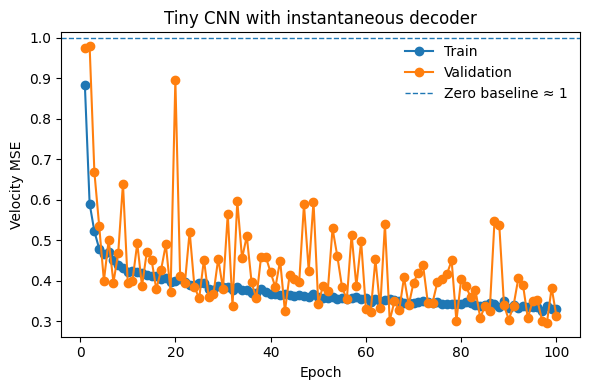

In [40]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], marker="o", label="Train")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation")
plt.axhline(1.0, linestyle="--", linewidth=1, label="Zero baseline ≈ 1")
plt.xlabel("Epoch")
plt.ylabel("Velocity MSE")
plt.title("Tiny CNN with instantaneous decoder")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [41]:
import numpy as np
import torch
import matplotlib.pyplot as plt


@torch.no_grad()
def compute_val_r2_per_movie(
    model,
    val_loader,
    vel_mean,
    vel_std,
    gray_frames,
    device,
):
    model.eval()

    r2_per_seq = []
    pred_all = []
    target_all = []

    for batch in val_loader:
        movie = batch["movie"].to(device)
        target = batch["scene_vel"].to(device)  # raw px/s, (B, T, 2)

        pred_z = model(movie)                   # normalized, (B, T, 2)
        pred = pred_z * vel_std + vel_mean      # back to px/s

        pred = pred[:, gray_frames:, :]
        target = target[:, gray_frames:, :]

        # Per movie R² over both vx and vy together
        ss_res = ((target - pred) ** 2).sum(dim=(1, 2))
        target_mean = target.mean(dim=(1, 2), keepdim=True)
        ss_tot = ((target - target_mean) ** 2).sum(dim=(1, 2))

        r2 = 1.0 - ss_res / (ss_tot + 1e-8)

        r2_per_seq.extend(r2.detach().cpu().numpy())
        pred_all.append(pred.detach().cpu())
        target_all.append(target.detach().cpu())

    r2_per_seq = np.asarray(r2_per_seq)
    pred_all = torch.cat(pred_all, dim=0)        # (Nval, T-gray, 2)
    target_all = torch.cat(target_all, dim=0)

    return r2_per_seq, pred_all, target_all

r2_per_seq, pred_val, target_val = compute_val_r2_per_movie(
    model=model,
    val_loader=val_loader,
    vel_mean=vel_mean,
    vel_std=vel_std,
    gray_frames=gray_frames,
    device=device,
)

mean_r2 = np.mean(r2_per_seq)
sem_r2 = np.std(r2_per_seq, ddof=1) / np.sqrt(len(r2_per_seq))

print("Mean R²:", mean_r2)
print("SEM R²:", sem_r2)
print("N validation movies:", len(r2_per_seq))
print("Min/Max R²:", r2_per_seq.min(), r2_per_seq.max())

Mean R²: 0.57764643
SEM R²: 0.014994752769439876
N validation movies: 390
Min/Max R²: -1.120383 0.9633354


/tmp/ipykernel_3380/2314121497.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


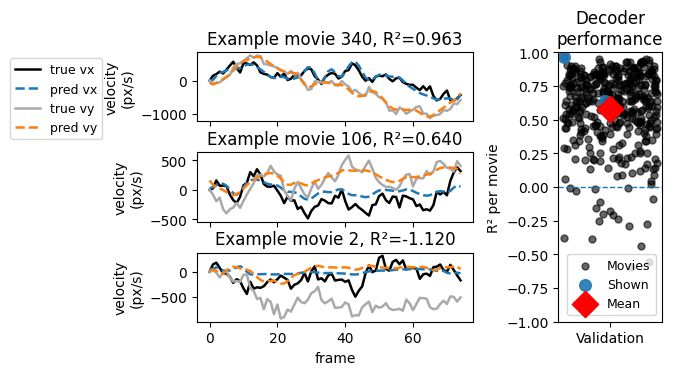

In [42]:
from matplotlib.gridspec import GridSpec


def plot_validation_summary_two_columns(
    r2_per_seq,
    pred_val,
    target_val,
    n_examples=3,
    example_mode="best",  # "best", "worst", or "mixed"
    figsize=(11, 7),
):
    # Convert tensors to numpy if needed
    if hasattr(pred_val, "detach"):
        pred_val_np = pred_val.detach().cpu().numpy()
    else:
        pred_val_np = np.asarray(pred_val)

    if hasattr(target_val, "detach"):
        target_val_np = target_val.detach().cpu().numpy()
    else:
        target_val_np = np.asarray(target_val)

    r2_per_seq = np.asarray(r2_per_seq)

    # Choose example indices
    order = np.argsort(r2_per_seq)

    if example_mode == "best":
        example_idxs = order[-n_examples:][::-1]
    elif example_mode == "worst":
        example_idxs = order[:n_examples]
    elif example_mode == "mixed":
        example_idxs = np.array([
            order[-1],
            order[len(order) // 2],
            order[0],
        ])
        example_idxs = example_idxs[:n_examples]
    else:
        raise ValueError("example_mode must be 'best', 'worst', or 'mixed'.")

    mean_r2 = np.mean(r2_per_seq)
    sem_r2 = np.std(r2_per_seq, ddof=1) / np.sqrt(len(r2_per_seq))

    # Figure layout
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(
        nrows=len(example_idxs),
        ncols=2,
        width_ratios=[3.2, 1.2],
        wspace=0.45,
        hspace=0.45,
        figure=fig,
    )

    # -----------------------------
    # Left column: example traces
    # -----------------------------
    for row, idx in enumerate(example_idxs):
        ax = fig.add_subplot(gs[row, 0])

        pred = pred_val_np[idx]
        target = target_val_np[idx]

        t = np.arange(target.shape[0])

        ax.plot(t, target[:, 0], label="true vx", linewidth=1.8, c='k')
        ax.plot(t, pred[:, 0], label="pred vx", linewidth=1.8, linestyle="--")

        ax.plot(t, target[:, 1], label="true vy", linewidth=1.8, c='darkgray')
        ax.plot(t, pred[:, 1], label="pred vy", linewidth=1.8, linestyle="--")

        ax.set_title(f"Example movie {idx}, R²={r2_per_seq[idx]:.3f}")
        ax.set_ylabel("velocity\n(px/s)")

        if row == len(example_idxs) - 1:
            ax.set_xlabel("frame")
        else:
            ax.set_xticklabels([])

        if row == 0:
            ax.legend(ncol=1, fontsize=9, loc="upper left",
                      bbox_to_anchor=(-.7, 1.0),)

    # -----------------------------
    # Right column: R² scatter plot
    # -----------------------------
    ax_r2 = fig.add_subplot(gs[:, 1])

    x0 = 0
    rng = np.random.default_rng(0)
    x_jitter = x0 + rng.uniform(-0.15, 0.15, size=len(r2_per_seq))

    ax_r2.scatter(
        x_jitter,
        r2_per_seq,
        alpha=0.6,
        s=25,
        c="k",
        label="Movies",
    )

    # Highlight selected examples
    ax_r2.scatter(
        x_jitter[example_idxs],
        r2_per_seq[example_idxs],
        alpha=0.9,
        s=70,
        c="tab:blue",
        label="Shown",
    )

    # Mean marker + SEM
    ax_r2.scatter(
        x0,
        mean_r2,
        s=180,
        marker="D",
        c="red",
        label="Mean",
        zorder=5,
    )

    ax_r2.errorbar(
        x0,
        mean_r2,
        yerr=sem_r2,
        fmt="none",
        ecolor="red",
        capsize=5,
        linewidth=2,
        zorder=4,
    )

    ax_r2.axhline(0, linestyle="--", linewidth=1)
    ax_r2.set_xticks([x0])
    ax_r2.set_xticklabels(["Validation"])
    ax_r2.set_ylim(-1, 1)
    ax_r2.set_ylabel("R² per movie")
    ax_r2.set_title("Decoder\nperformance")
    ax_r2.legend(fontsize=9, loc="lower right")

    # fig.suptitle("Validation performance summary", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

    return fig

fig = plot_validation_summary_two_columns(
    r2_per_seq=r2_per_seq,
    pred_val=pred_val,
    target_val=target_val,
    n_examples=3,
    example_mode="mixed",
    figsize=(6, 3.5),
)